### Real-data held-out validation on NJ2 dataset
- data: NJ2 quality ratings
- train/test split: 7736 train rows, 1867 test rows (~20% of rating events)

In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
from scipy.special import logsumexp, softmax
from scipy.stats import mode
from settings import ROOT_DIR
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
FIT_PATH = Path(ROOT_DIR/'model_runs/cross_val_nj2_quality/fit_seasonality_nj2_quality_cross_val.pkl')
TEST_PATH = Path(ROOT_DIR/'model_runs/cross_val_nj2_quality/test_data.pkl')
TARGET_COL = 'value'

with FIT_PATH.open('rb') as f:
    fit_data = pickle.load(f)
with TEST_PATH.open('rb') as f:
    test_data = pickle.load(f)

# load actual and predicted ratings
y_true = test_data[TARGET_COL].to_numpy().astype(int)
y_rep = np.asarray(fit_data.stan_variable('y_rep_test'))
y_pred = mode(y_rep, axis=0, keepdims=False).mode.astype(int)

# held-out log predictive density
ll_test = np.asarray(fit_data.stan_variable('log_lik_test'))
held_out_log_score = logsumexp(ll_test, axis=0) - np.log(ll_test.shape[0])

# ranked probability score calculations
plot_effect = np.asarray(fit_data.stan_variable('plot_effect'))
time_effect_test = np.asarray(fit_data.stan_variable('time_effect_test'))
tau_rater = np.asarray(fit_data.stan_variable('tau_rater'))
plot_idx = test_data['plot_code'].to_numpy().astype(int) - 1
entry_idx = test_data['entry_code'].to_numpy().astype(int) - 1
rater_idx = test_data['rater_code'].to_numpy().astype(int) - 1
rating_idx = test_data['rating_event_code_test'].to_numpy().astype(int) - 1
K = int(y_true.max()) + 1
rps = np.empty(len(y_pred), dtype=float)
for i in range(len(y_pred)):
    theta = plot_effect[:, plot_idx[i]] + time_effect_test[:, entry_idx[i], rating_idx[i]]
    tau_i = tau_rater[:, rater_idx[i], :]
    logits = np.cumsum(np.concatenate([np.zeros((theta.shape[0], 1)), theta[:, None] - tau_i], axis=1), axis=1)
    probs = softmax(logits, axis=1)
    cdf_pred = np.cumsum(probs, axis=1)
    cdf_obs = np.zeros(K, dtype=float)
    cdf_obs[y_true[i]:] = 1.0
    rps[i] = np.mean(np.sum((cdf_pred - cdf_obs) ** 2, axis=1) / (K - 1))

/users/2/oboiko/.conda/envs/nteprsm_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
exact_accuracy = np.mean(y_pred == y_true)
print(exact_accuracy)

0.3294054633101232


In [4]:
adj_accuracy = np.mean(np.abs(y_pred - y_true) <= 1)
print(adj_accuracy)

0.7750401713979647


In [5]:
held_out_log_score_mean = held_out_log_score.mean()
print(held_out_log_score_mean)

-1.5954518932321233


In [6]:
rps_mean = rps.mean()
print(rps_mean)

0.08848639175634625


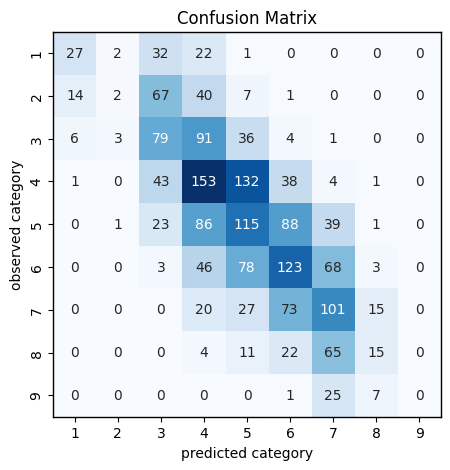

In [7]:
# compute the confusion matrix
# 9 categories, so 9x9 array
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 5))
ax = sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=range(1, 10), 
    yticklabels=range(1, 10),
    cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('observed category')
plt.xlabel('predicted category')
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color('black')
plt.show()

In [8]:
# predicted and observed category frequencies
cats = np.arange(max(y_true.max(), y_pred.max()) + 1)
obs_counts = np.bincount(y_true, minlength=len(cats))
pred_counts = np.bincount(y_pred, minlength=len(cats))
freq_df = pd.DataFrame({
    'category': cats,
    'observed_freq': obs_counts / obs_counts.sum(),
    'predicted_freq': pred_counts / pred_counts.sum(),
})

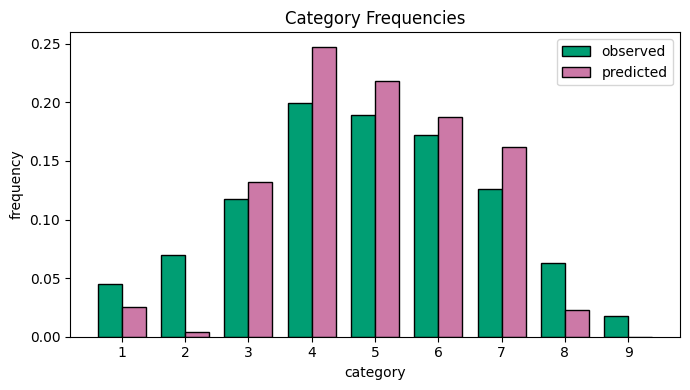

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(9)
width = 0.38
ax.bar(
    x - width / 2, freq_df['observed_freq'], width=width,
    label='observed', facecolor='#009E73', edgecolor='black')
ax.bar(
    x + width / 2, freq_df['predicted_freq'], width=width,
    label='predicted', facecolor='#CC79A7', edgecolor='black')
ax.set_xlabel('category')
ax.set_ylabel('frequency')
ax.set_title('Category Frequencies')
ax.set_xticks(x, labels=[str(i) for i in range(1, 10)])
ax.legend()
plt.tight_layout()
plt.show()